In [14]:
import os
import pandas as pd

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

### Data exploration

In [3]:
CREMA_D_BASE_DIR = "audio_speech/CREMA_D"

In [4]:
error_files = [
    '1076_MTI_NEU_XX.wav', # very short, no audio
    '1076_MTI_SAD_XX.wav', # no audio, very short
    '1064_TIE_SAD_XX.wav', # file has no duration
    '1064_IEO_DIS_MD.wav' # this file is actually 1 minute long and has all emotional displays for It's Eleven O'clock.
    ]

In [5]:
crema_directory_list = os.listdir(CREMA_D_BASE_DIR)

file_emotion = []
file_path = []

for file in crema_directory_list:
    # skip file if is in error list
    if file in error_files:
        continue

    # Get path of each audio file
    file_path.append(CREMA_D_BASE_DIR + '/' + file)

    # Extract emotion
    emotion = file.split('_')[2] # split returns e.g. ['1001', 'DFA', 'ANG', 'XX.mp3'], emotion is in pos 2

    # To match the ravdess encodings
    if emotion == 'SAD':
        file_emotion.append(3)
    elif emotion == 'ANG':
        file_emotion.append(4)
    elif emotion == 'DIS':
        file_emotion.append(6)
    elif emotion == 'FEA':
        file_emotion.append(5)
    elif emotion == 'HAP':
        file_emotion.append(2)
    elif emotion == 'NEU':
        file_emotion.append(1)
    else:
        file_emotion.append(0)

In [6]:
df = pd.DataFrame(list(zip(file_path, file_emotion)), columns=['file_path', 'Emotion'])
df.head()

,file_path,Emotion
0,audio_speech/CREMA_D/1001_DFA_ANG_XX.wav,4
1,audio_speech/CREMA_D/1001_DFA_DIS_XX.wav,6
2,audio_speech/CREMA_D/1001_DFA_FEA_XX.wav,5
3,audio_speech/CREMA_D/1001_DFA_HAP_XX.wav,2
4,audio_speech/CREMA_D/1001_DFA_NEU_XX.wav,1


In [7]:
# Add human readable labels to the emotions
emotion_map = {
    1: "neutral",
    2: "happy",
    3: "sad",
    4: "angry",
    5: "fearful",
    6: "disgust",
    7: "surprised"
}

df["Emotion_label"] = df["Emotion"].map(emotion_map)

In [8]:
df.Emotion_label.value_counts().sort_index()

Emotion_label
angry      1096
disgust    1095
fearful    1096
happy      1096
neutral     934
sad        1093
Name: count, dtype: int64

In [9]:
df.head()

,file_path,Emotion,Emotion_label
0,audio_speech/CREMA_D/1001_DFA_ANG_XX.wav,4,angry
1,audio_speech/CREMA_D/1001_DFA_DIS_XX.wav,6,disgust
2,audio_speech/CREMA_D/1001_DFA_FEA_XX.wav,5,fearful
3,audio_speech/CREMA_D/1001_DFA_HAP_XX.wav,2,happy
4,audio_speech/CREMA_D/1001_DFA_NEU_XX.wav,1,neutral


## Export dataset

In [10]:
df.to_csv("crema_d_labels.csv", index=False)

### Explore Dataset

In [11]:
df

,file_path,Emotion,Emotion_label
0,audio_speech/CREMA_D/1001_DFA_ANG_XX.wav,4,angry
1,audio_speech/CREMA_D/1001_DFA_DIS_XX.wav,6,disgust
2,audio_speech/CREMA_D/1001_DFA_FEA_XX.wav,5,fearful
3,audio_speech/CREMA_D/1001_DFA_HAP_XX.wav,2,happy
4,audio_speech/CREMA_D/1001_DFA_NEU_XX.wav,1,neutral
...,...,...,...
6405,audio_speech/CREMA_D/1079_ITH_SAD_XX.wav,3,sad
6406,audio_speech/CREMA_D/1079_ITS_ANG_XX.wav,4,angry
6407,audio_speech/CREMA_D/1079_ITS_DIS_XX.wav,6,disgust
6408,audio_speech/CREMA_D/1079_ITS_FEA_XX.wav,5,fearful


In [15]:
# Get duration of each audio clip
durations = []  # to store each file's duration

for path in df['file_path']:
    try:
        y, sr = librosa.load(path, sr=None)  # sr=None preserves original sampling rate
        duration = librosa.get_duration(y=y, sr=sr)
        durations.append(duration)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        durations.append(None)

# Add durations to dataframe
df['duration'] = durations


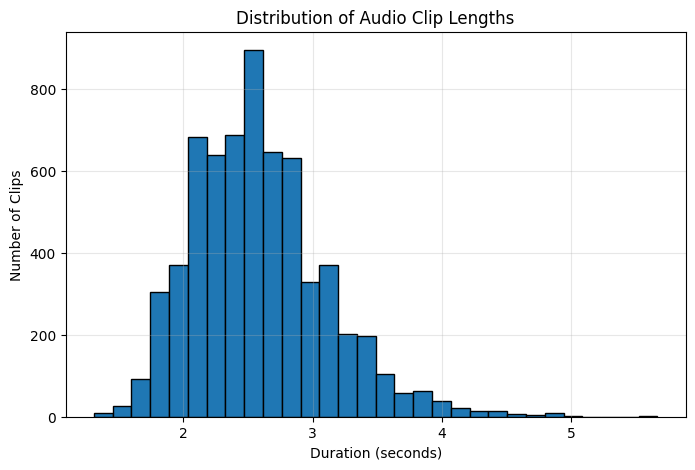

In [16]:
# Plot distribution of audio clip length
plt.figure(figsize=(8, 5))
plt.hist(df['duration'], bins=30, edgecolor='black')
plt.title('Distribution of Audio Clip Lengths')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Clips')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Find min & max audio duration
shortest = df.loc[df['duration'].idxmin()]
longest = df.loc[df['duration'].idxmax()]

print(f"Shortest clip: {shortest['file_path']} ({shortest['duration']:.2f} sec)")
print(f"Longest clip: {longest['file_path']} ({longest['duration']:.2f} sec)")

Shortest clip: audio_speech/CREMA_D/1065_IEO_DIS_HI.wav (1.31 sec)
Longest clip: audio_speech/CREMA_D/1047_IEO_SAD_LO.wav (5.67 sec)


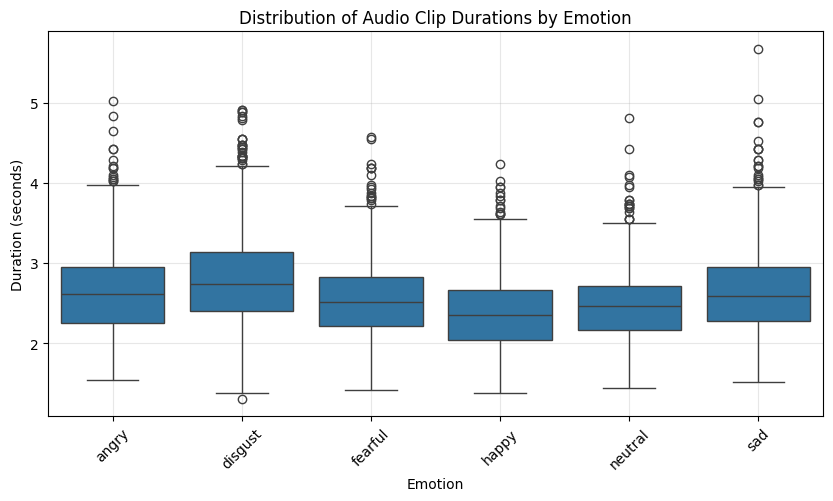

In [18]:
# Distribution of Audio Clip Durations by Emotion
plt.figure(figsize=(10, 5))
sns.boxplot(x='Emotion_label', y='duration', data=df)
plt.title('Distribution of Audio Clip Durations by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()